# Data Cleaning - VNExpress News Dataset

Dataset được crawl từ hai chuyên mục:

- Sức khỏe
- Giải trí

Notebook này thực hiện:

1. Kiểm tra dữ liệu thô
2. Làm sạch dữ liệu
3. Chuẩn hóa định dạng
4. Tạo feature mới
5. Xuất dataset sạch để phân tích tiếp

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

## 2. Đọc dữ liệu thô

In [2]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1219, 11)


,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,Vì sao ăn bánh mì có thể ngộ độc?,"Các nguyên liệu trong bánh mì như pate, thịt n...","Thứ sáu, 6/3/2026, 08:00 (GMT+7)",Từ đầu tháng 3 đến nay miền Nam liên tiếp xảy ...,https://i1-suckhoe.vnecdn.net/2026/03/06/ba-nh...,Quyên Phan,"ngộ độc thực phẩm, bánh mì",Các bệnh,Tiêu hóa,16,https://vnexpress.net/vi-sao-an-banh-mi-co-the...
1,Khám đau cột sống bất ngờ phát hiện hẹp van tim,"TP HCMÔng Sang, 59 tuổi, đau cột sống thắt lưn...","Thứ năm, 5/3/2026, 09:00 (GMT+7)","TS.BS Trần Vũ Minh Thư, Trưởng khoa Nội tim mạ...",https://i1-suckhoe.vnecdn.net/2026/03/05/image...,Thu Hà,"tp hcm, hẹp van tim, khám cột sống, bệnh tim mạch",Các bệnh,Tim mạch,0,https://vnexpress.net/kham-dau-cot-song-bat-ng...
2,"Thời trang đồng điệu của Kỳ Duyên, Đoàn Thiên Ân","Hoa hậu Kỳ Duyên, Thiên Ân thường chọn trang c...","Thứ sáu, 27/2/2026, 08:12 (GMT+7)","Dịp Tết Bính Ngọ, hai hoa hậu dành thời gian d...",https://i1-giaitri.vnecdn.net/2026/02/23/Ky-Du...,Tân Cao,"hoa hậu kỳ duyên, đoàn thiên ân, sao việt diện...",Giải trí,Thời trang,1,https://vnexpress.net/thoi-trang-dong-dieu-cua...
3,Dàn sao dạo đường hoa Nguyễn Huệ ngày khai mạc,TP HCMVợ chồng Tăng Thanh Hà cùng dàn sao diện...,"Chủ nhật, 15/2/2026, 23:01 (GMT+7)",Tăng Thanh Hà và chồng - doanh nhân Louis Nguy...,https://i1-giaitri.vnecdn.net/2026/02/15/tang-...,MC Thư Đình nhảy múa trên nền nhạc ca khúcVạn ...,"vợ chồng tăng thanh hà, khai mạc đường hoa ngu...",Giải trí,Giới sao,5,https://vnexpress.net/dan-sao-dao-duong-hoa-ng...
4,Phim về bà Melania Trump hút khán giả dù bị ch...,"Phim tài liệu ""Melania: Twenty Days to History...","Thứ tư, 4/2/2026, 00:00 (GMT+7)",Tác phẩm do Brett Ratner đạo diễn ra rạp Mỹ hô...,https://i1-giaitri.vnecdn.net/2026/02/03/melan...,Cát Tiên,"melania trump, phim tài liệu, melania: twenty ...",Giải trí,Phim,9,https://vnexpress.net/phim-ve-ba-melania-trump...


## 3. Thông tin dữ liệu

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             1214 non-null   str  
 1   description       1217 non-null   str  
 2   date              1214 non-null   str  
 3   content           1214 non-null   str  
 4   thumbnail         1219 non-null   str  
 5   author            1219 non-null   str  
 6   tags              1219 non-null   str  
 7   group             1219 non-null   str  
 8   category          1219 non-null   str  
 9   nums_of_comments  1219 non-null   int64
 10  url               1219 non-null   str  
dtypes: int64(1), str(10)
memory usage: 104.9 KB


## 4. Kiểm tra dữ liệu thiếu

In [4]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
title,5,0.410172
date,5,0.410172
content,5,0.410172
description,2,0.164069
thumbnail,0,0.000000
author,0,0.000000
tags,0,0.000000
group,0,0.000000
category,0,0.000000
nums_of_comments,0,0.000000


## 5. Xử lý dữ liệu thời gian bị thiếu

## 5. Phân bố dữ liệu ban đầu

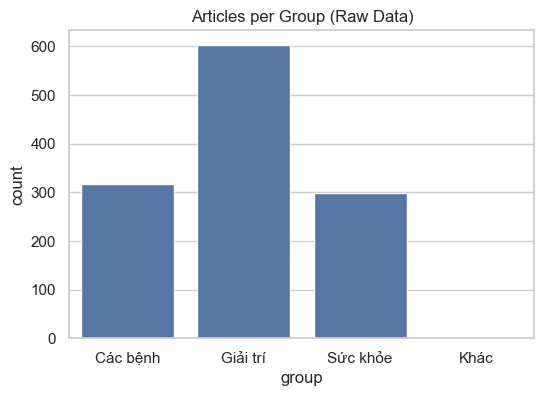

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="group")

plt.title("Articles per Group (Raw Data)")
plt.show()

# 6. Loại bỏ dữ liệu trùng lặp

In [6]:
print("Rows before:", len(df))

df = df.drop_duplicates(subset="url")

print("Rows after:", len(df))

Rows before: 1219
Rows after: 1219


## 7. Loại bỏ bài viết thiếu nội dung

In [7]:
df = df.dropna(subset=["title", "content"])

print("Rows after removing missing:", len(df))

Rows after removing missing: 1214


# 8. Làm sạch dữ liệu văn bản

In [8]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [9]:
df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

## 9. Phân tích độ dài văn bản

In [10]:
df["title_length"] = df["title"].apply(lambda x: len(x.split()))
df["content_length"] = df["content"].apply(lambda x: len(x.split()))

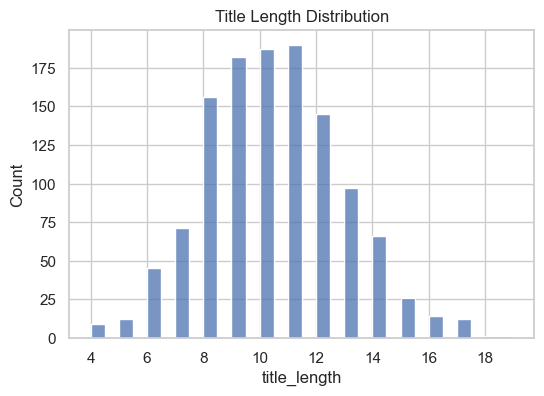

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

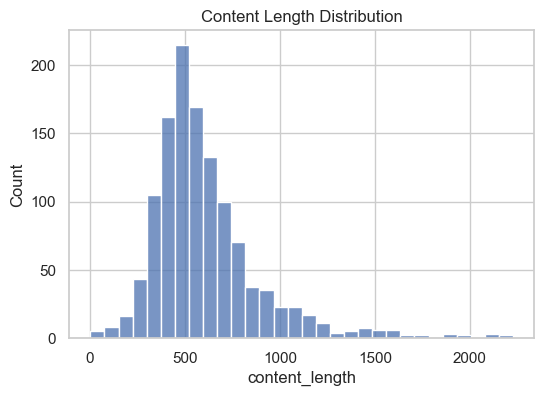

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

# 10. Chuẩn hóa định dạng ngày

In [13]:
def clean_date(text):

    if pd.isna(text):
        return text

    text = re.sub(r'^Thứ.*?,\s*', '', text)

    text = re.sub(r'\(.*?\)', '', text)

    return text.strip()

In [14]:
df["date"] = df["date"].apply(clean_date)

In [15]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y, %H:%M",
    errors="coerce"
)

## 11. Chuẩn hóa group/category

In [16]:


def normalize_category(row):
    group = row["group"]
    category = row["category"]

    # Trường hợp crawler lấy được: Các bệnh > Hô hấp

    # Nếu muốn làm theo hướng gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    # if group == "Các bệnh":
    #     group = "Sức khỏe"
    #     category = "Các bệnh"

    # Nếu muốn giữ nguyên các nhóm riêng biệt, nhưng vẫn gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    if group == "Các bệnh":
        group = "Sức khỏe"

    return pd.Series([group, category])


df[["group", "category"]] = df.apply(normalize_category, axis=1)

# print("Unique groups:", df["group"].unique())
# print("Unique categories:", df["category"].unique())

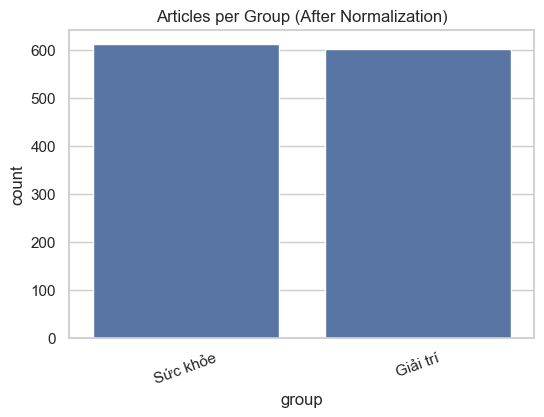

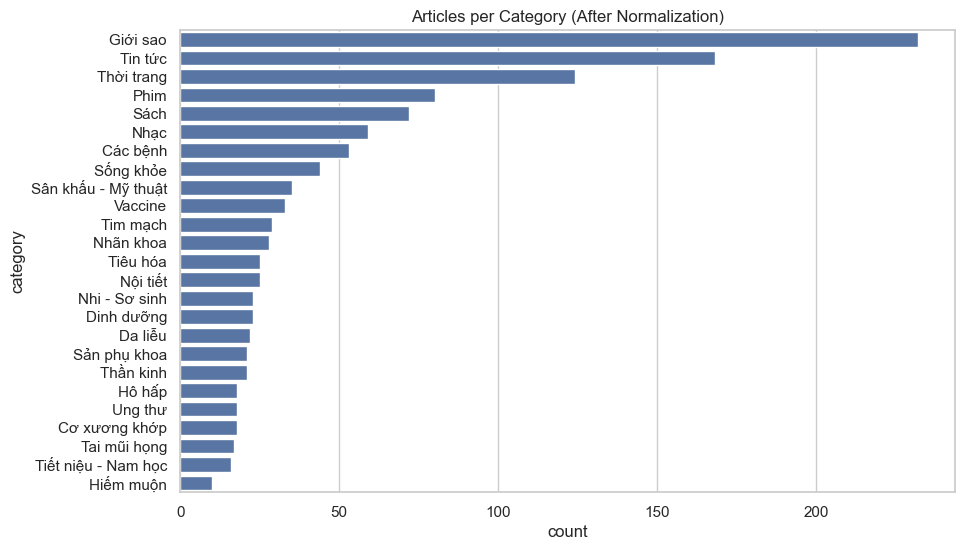

In [17]:
# Visualize group distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="group")
plt.title("Articles per Group (After Normalization)")
plt.xticks(rotation=20)
plt.show()


# Visualize category distribution

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
plt.title("Articles per Category (After Normalization)")

plt.show()

## 12. Tạo feature thời gian

In [18]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

# Điền giá trị null
df = df.fillna({
    "date": pd.to_datetime("2026-01-01 07:00:00"),
    "year": 2026.0,
    "month": 1.0,
    "hour": 7.0,
    "description": "",
    "thumbnail": "No Image",
    "tags": "Notag",
    'author': 'Không xác định',
})

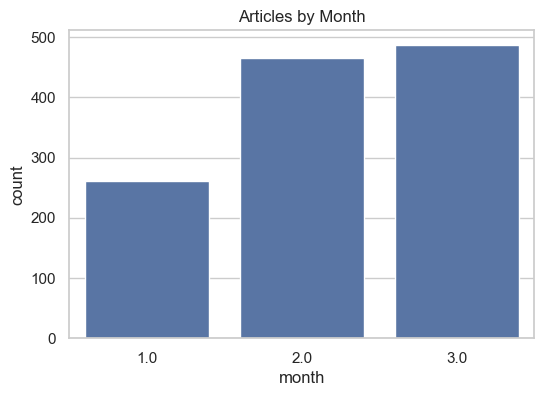

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="month")

plt.title("Articles by Month")

plt.show()

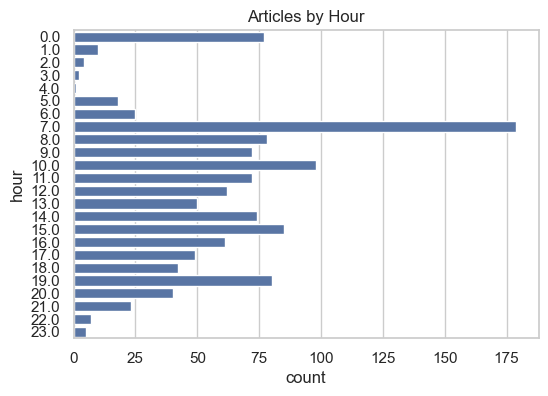

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, y="hour")

plt.title("Articles by Hour")

plt.show()

## 13. Phân tích số lượng bình luận

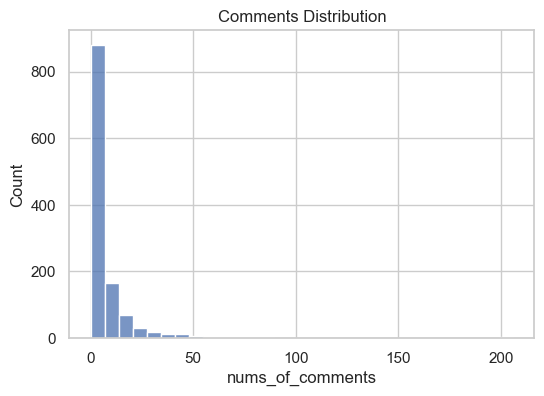

In [21]:
plt.figure(figsize=(6,4))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Comments Distribution")

plt.show()

## 14. Kiểm tra dataset sau khi clean

In [22]:
df.info()

<class 'pandas.DataFrame'>
Index: 1214 entries, 0 to 1218
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             1214 non-null   str           
 1   description       1214 non-null   str           
 2   date              1214 non-null   datetime64[us]
 3   content           1214 non-null   str           
 4   thumbnail         1214 non-null   str           
 5   author            1214 non-null   str           
 6   tags              1214 non-null   str           
 7   group             1214 non-null   str           
 8   category          1214 non-null   str           
 9   nums_of_comments  1214 non-null   int64         
 10  url               1214 non-null   str           
 11  title_length      1214 non-null   int64         
 12  content_length    1214 non-null   int64         
 13  year              1214 non-null   float64       
 14  month             1214 non-null   float6

In [23]:
df.describe()

,date,nums_of_comments,title_length,content_length,year,month,hour
count,1214,1214.000000,1214.000000,1214.000000,1214.0,1214.000000,1214.000000
mean,2026-02-18 01:57:17.149917,7.578254,10.287479,607.763591,2026.0,2.186161,11.455519
min,2026-01-01 07:00:00,0.000000,4.000000,2.000000,2026.0,1.000000,0.000000
25%,2026-02-05 09:13:00,0.000000,9.000000,433.000000,2026.0,2.000000,7.000000
50%,2026-02-26 00:00:00,2.000000,10.000000,544.500000,2026.0,2.000000,11.000000
75%,2026-03-06 08:00:00,7.000000,12.000000,706.750000,2026.0,3.000000,16.000000
max,2026-03-14 00:03:00,206.000000,19.000000,2228.000000,2026.0,3.000000,23.000000
std,NaN,18.500553,2.448929,290.163761,0.0,0.762868,5.421485


## 15. Lưu dataset đã clean

In [24]:
df.to_csv("../data/vnexpress_clean_data.csv", index=False)

print("Saved clean dataset")

Saved clean dataset
